# Классификация изображений одежды (Feedforward Neural Network)

**Датасет:** [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist) — 70k изображений одежды 28x28, 10 классов
**Задача:** классификация типа одежды по изображению с помощью нейросети прямого распространения

## 1. Краткая теория

**Feedforward нейросеть** для классификации: сигнал проходит через скрытые слои с нелинейными активациями (ReLU), выходной слой — softmax. Обучение через backpropagation с минимизацией Cross-Entropy Loss.

Каждый нейрон вычисляет: $z = \sum w_i x_i + b$, $a = \sigma(z)$. На выходном слое softmax преобразует логиты в вероятности классов:

$$\sigma(z_j) = \frac{e^{z_j}}{\sum_{k=1}^{K} e^{z_k}}$$

Подробная теория — в [README.md](README.md).

## 2. Загрузка данных

In [1]:
%%capture
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# загрузка Fashion MNIST
transform = transforms.ToTensor()
train_data = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

class_names = ['Футболка', 'Брюки', 'Свитер', 'Платье', 'Пальто',
               'Сандалии', 'Рубашка', 'Кроссовки', 'Сумка', 'Ботинки']

In [2]:
print(f"Обучение: {len(train_data)}, Тест: {len(test_data)}")
print(f"Размер изображения: {train_data[0][0].shape}")

Обучение: 60000, Тест: 10000
Размер изображения: torch.Size([1, 28, 28])


## 3. Первичный анализ

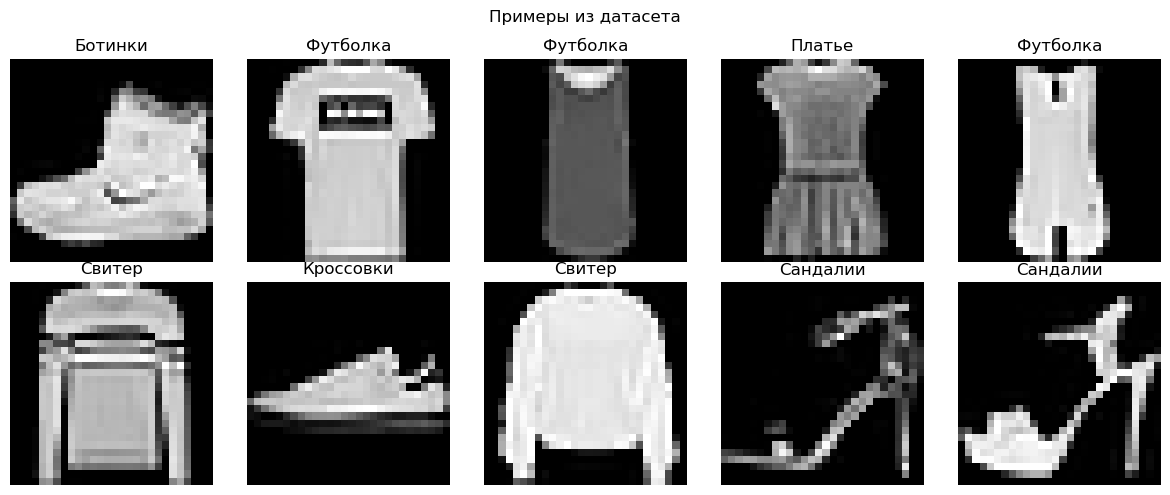

In [3]:
# примеры изображений
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, label = train_data[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(class_names[label])
    ax.axis('off')
plt.suptitle('Примеры из датасета')
plt.tight_layout()
plt.show()

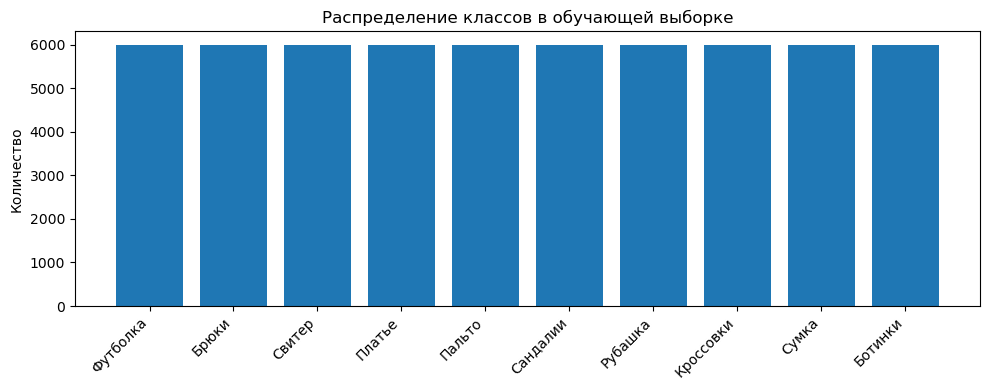

Классы сбалансированы: 6000 - 6000 примеров на класс


In [4]:
# распределение классов
train_labels = [label for _, label in train_data]
counts = pd.Series(train_labels).value_counts().sort_index()

plt.figure(figsize=(10, 4))
plt.bar(range(10), counts.values)
plt.xticks(range(10), class_names, rotation=45, ha='right')
plt.ylabel('Количество')
plt.title('Распределение классов в обучающей выборке')
plt.tight_layout()
plt.show()

print(f'Классы сбалансированы: {counts.min()} - {counts.max()} примеров на класс')

Классы идеально сбалансированы (6000 на класс в train), поэтому accuracy адекватно отражает качество модели.

## 4. Предобработка

In [5]:
# нормализация [0, 1] уже выполнена transforms.ToTensor()
# преобразуем в плоские векторы 784 для feedforward сети

X_train = train_data.data.float().view(-1, 784) / 255.0
y_train = train_data.targets
X_test = test_data.data.float().view(-1, 784) / 255.0
y_test = test_data.targets

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'Диапазон значений: [{X_train.min():.1f}, {X_train.max():.1f}]')

X_train: torch.Size([60000, 784]), X_test: torch.Size([10000, 784])
Диапазон значений: [0.0, 1.0]


In [6]:
# DataLoader для батчевого обучения
batch_size = 128

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=batch_size, shuffle=True
)
test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=batch_size, shuffle=False
)

print(f'Батчей: train={len(train_loader)}, test={len(test_loader)}')

Батчей: train=469, test=79


## 5. Обучение модели

In [7]:
# архитектура: 784 -> 256 -> 128 -> 10
class FashionNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 10)
        )
    
    def forward(self, x):
        return self.net(x)

model = FashionNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\nПараметров: {total_params:,}')

FashionNet(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)

Параметров: 235,146


In [8]:
# обучение
epochs = 30
train_losses = []
test_losses = []
test_accs = []

for epoch in range(epochs):
    # train
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)
    train_losses.append(running_loss / len(train_loader.dataset))
    
    # eval
    model.eval()
    test_loss = 0.0
    correct = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            output = model(X_batch)
            test_loss += criterion(output, y_batch).item() * X_batch.size(0)
            pred = output.argmax(dim=1)
            correct += (pred == y_batch).sum().item()
    test_losses.append(test_loss / len(test_loader.dataset))
    test_accs.append(correct / len(test_loader.dataset))
    
    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1:2d}/{epochs}  '
              f'train_loss={train_losses[-1]:.4f}  '
              f'test_loss={test_losses[-1]:.4f}  '
              f'test_acc={test_accs[-1]:.4f}')

Epoch  5/30  train_loss=0.3305  test_loss=0.3463  test_acc=0.8767


Epoch 10/30  train_loss=0.2787  test_loss=0.3157  test_acc=0.8873


Epoch 15/30  train_loss=0.2505  test_loss=0.3145  test_acc=0.8907


Epoch 20/30  train_loss=0.2308  test_loss=0.3169  test_acc=0.8928


Epoch 25/30  train_loss=0.2133  test_loss=0.3143  test_acc=0.8907


Epoch 30/30  train_loss=0.1983  test_loss=0.3166  test_acc=0.8953


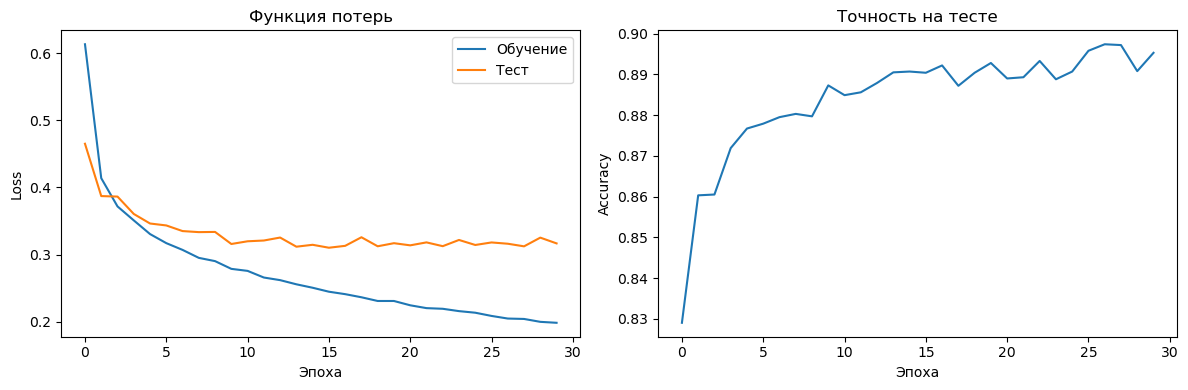

Лучшая accuracy: 0.8974 (эпоха 27)


In [9]:
# графики обучения
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Обучение')
ax1.plot(test_losses, label='Тест')
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Loss')
ax1.set_title('Функция потерь')
ax1.legend()

ax2.plot(test_accs)
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Accuracy')
ax2.set_title('Точность на тесте')

plt.tight_layout()
plt.show()

print(f'Лучшая accuracy: {max(test_accs):.4f} (эпоха {np.argmax(test_accs)+1})')

Test loss стабилизируется с ~15 эпохи, в то время как train loss продолжает падать — признак лёгкого переобучения. Dropout(0.2) частично компенсирует это.

## 6. Оценка качества

In [10]:
# предсказания на тесте
model.eval()
with torch.no_grad():
    y_pred = model(X_test).argmax(dim=1).numpy()
y_true = y_test.numpy()

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    Футболка       0.83      0.88      0.85      1000
       Брюки       0.99      0.98      0.98      1000
      Свитер       0.83      0.79      0.81      1000
      Платье       0.91      0.88      0.90      1000
      Пальто       0.78      0.86      0.82      1000
    Сандалии       0.98      0.96      0.97      1000
     Рубашка       0.74      0.70      0.72      1000
   Кроссовки       0.94      0.98      0.96      1000
       Сумка       0.98      0.98      0.98      1000
     Ботинки       0.97      0.95      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



Лучший F1 у Trouser (0.98) и Bag (0.98) — визуально уникальные классы. Худший у Shirt (0.72) — модель путает его с T-shirt/top, Pullover и Coat.

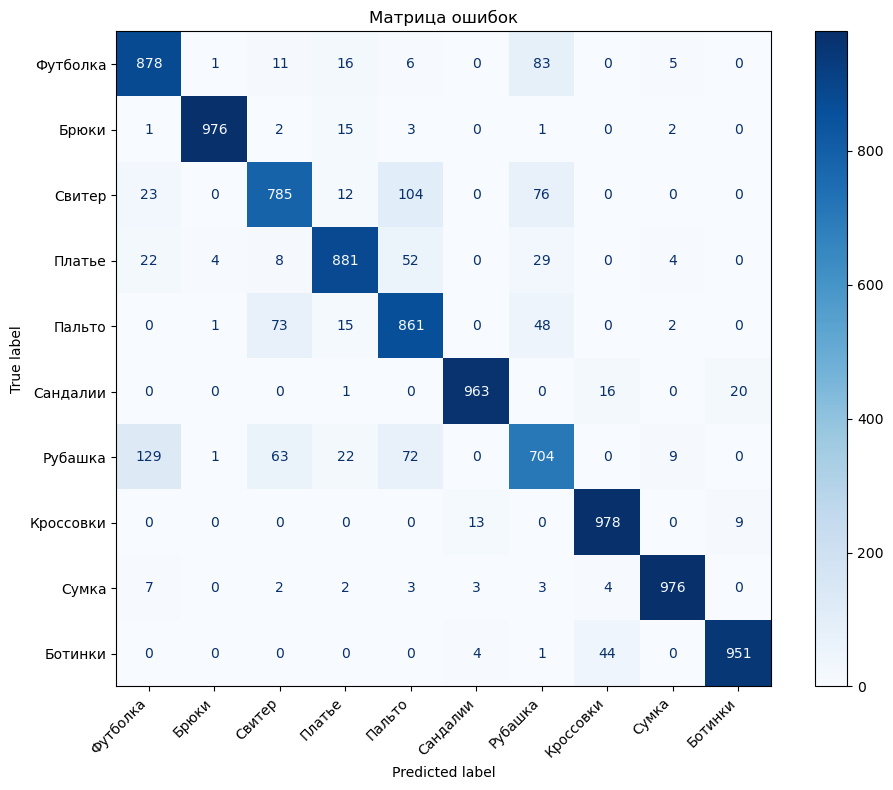

In [11]:
# confusion matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Матрица ошибок')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

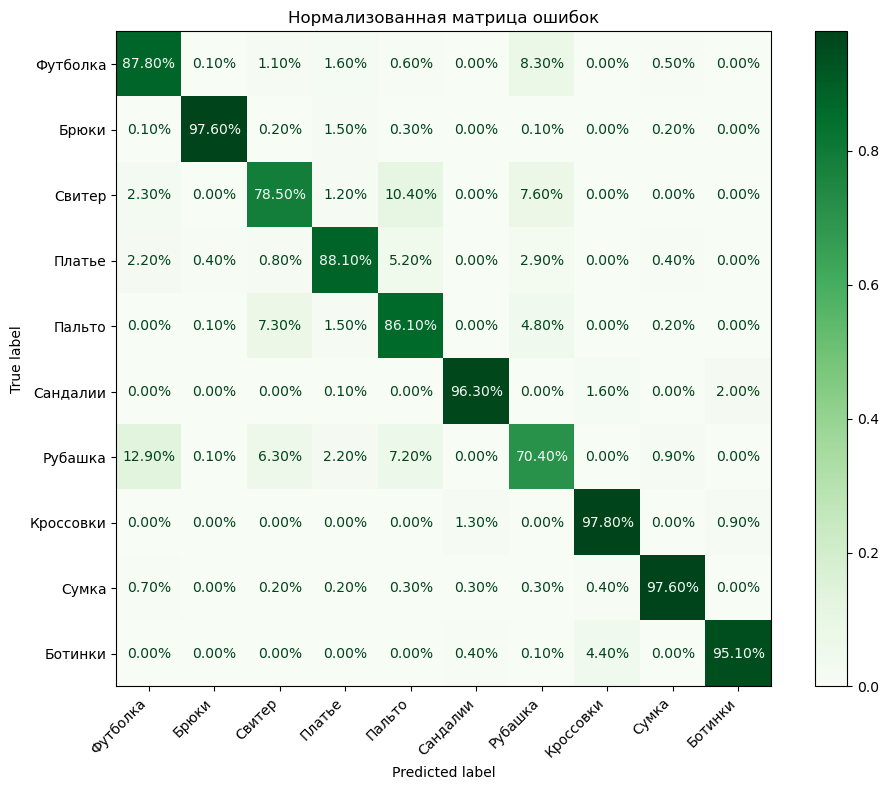

In [12]:
# нормализованная confusion matrix
cm_norm = confusion_matrix(y_true, y_pred, normalize='true')
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(cm_norm, display_labels=class_names)
disp.plot(ax=ax, cmap='Greens', values_format='.2%')
plt.title('Нормализованная матрица ошибок')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Shirt путается с T-shirt/top в 15% случаев и с Pullover в 7% — все три класса представляют верхнюю одежду со схожим силуэтом на 28x28.

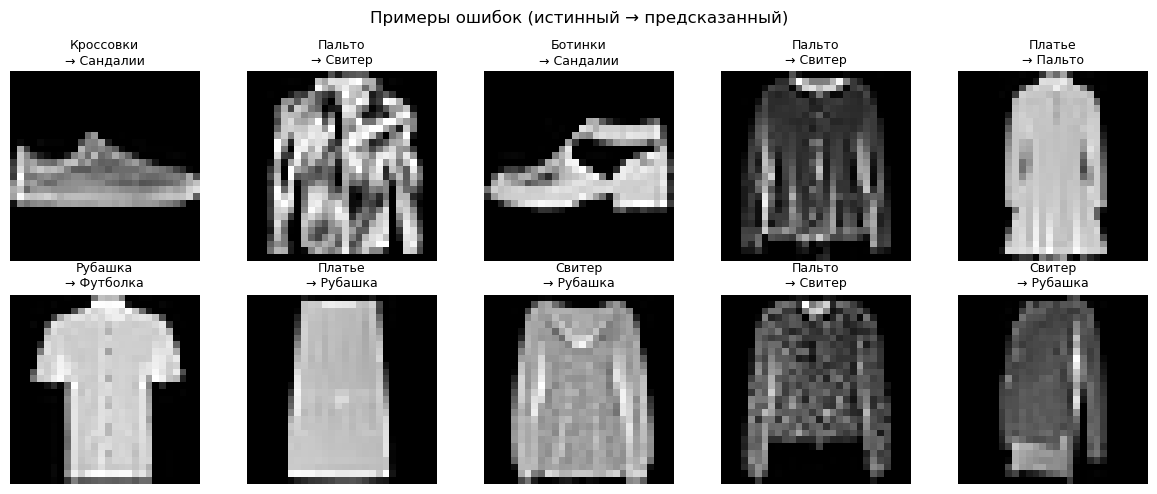

Всего ошибок: 1047 из 10000 (10.5%)


In [13]:
# примеры ошибок
errors = np.where(y_pred != y_true)[0]
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    idx = errors[i]
    img = X_test[idx].view(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f'{class_names[y_true[idx]]}\n→ {class_names[y_pred[idx]]}', fontsize=9)
    ax.axis('off')
plt.suptitle('Примеры ошибок (истинный → предсказанный)')
plt.tight_layout()
plt.show()

print(f'Всего ошибок: {len(errors)} из {len(y_true)} ({len(errors)/len(y_true)*100:.1f}%)')

Ошибки модели визуально обоснованы: перепутанные предметы действительно похожи на изображениях низкого разрешения.